In [1]:
from pathlib import Path
import json, yaml, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import seaborn as sns

import matplotlib
# matplotlib.use('Agg')


In [2]:
df_rsna = pd.read_csv("data/embed_mendeley_with_aug.csv")
df_mendeley = pd.read_csv("data/embed_rsna_with_aug.csv")

df_rsna = df_rsna[df_rsna['aug_k'] == 0]
df_mendeley = df_mendeley[df_mendeley['aug_k'] == 0]
n_samples_rsna = df_rsna.shape[0]
n_samples_mendeley = df_mendeley.shape[0]

In [3]:
n_samples_rsna, n_samples_mendeley

(18679, 19220)

In [3]:
def run_folder_to_df_with_clients(run_folder: Path, prefer_meta: bool = True):
    """
    Returns:
      run_df:    per-round DataFrame with run-level metrics (chosen macro_f1), timings, aggregated picks, + YAML params
      client_df: per-round, per-client DataFrame with RF/META metrics (if present) and client-level picked counts
 
    NEW in Experiment 1:
      - run_df includes test_macro_f1, test_rf_macro_f1, test_meta_macro_f1
        (from the fixed holdout set logged under "avg_test")
      - client_df includes test_rf_macro_f1, test_meta_macro_f1
        (from per-client "test_rf" / "test_meta" entries)
    """
    run_folder = Path(run_folder)
 
    # ----- pick YAML -----
    yaml_paths = sorted(run_folder.glob("*.yaml"))
    if not yaml_paths:
        raise FileNotFoundError(f"No YAML found in {run_folder}")
    yaml_path = next((p for p in yaml_paths if p.name.startswith("derived_")), yaml_paths[0])
 
    # ----- pick JSONL -----
    jsonl_paths = list(run_folder.glob("*.jsonl"))
    if not jsonl_paths:
        raise FileNotFoundError(f"No JSONL found in {run_folder}")
    jsonl_path = max(jsonl_paths, key=lambda p: p.stat().st_size)
 
    # ----- load YAML -----
    with open(yaml_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
 
    def g(node, path, default=None):
        cur = node
        for k in path.split("."):
            if not isinstance(cur, dict): return default
            cur = cur.get(k)
        return cur if cur is not None else default
 
    params = {
        "seed_k":            g(cfg, "seed_k"),
        "rounds":            g(cfg, "rounds"),
        "al_method_cfg":     g(cfg, "al.method"),
        "batch_B":           g(cfg, "al.batch_B"),
        "per_class_min":     g(cfg, "al.per_class_min"),
        "aug_K":             g(cfg, "augment.train_n_per_sample"),
        "meta_mode":         g(cfg, "meta.aug_mode"),
        "tta_n":             g(cfg, "meta.tta_n"),
        "meta_lambda":       g(cfg, "meta.lambda"),
        "rf_n_estimators":   g(cfg, "rf.n_estimators"),
        "rf_max_features":   g(cfg, "rf.max_features"),
        "seeding_method":    g(cfg, "seeding.method"),
        "holdout_frac":      g(cfg, "holdout.test_frac"),       # Exp 1
        # Exp 2: partition config
        "partition_method":  g(cfg, "partition.method"),
        "n_clients":         g(cfg, "partition.n_clients"),
        "dirichlet_alpha":   g(cfg, "partition.alpha"),
        # Exp 3: meta-feature ablation
        "feature_groups":    g(cfg, "meta.feature_groups"),
        # Exp 3b/3c: heterogeneous RF and noise
        "heterogeneous_rf":  cfg.get("heterogeneous_rf"),
        "emb_noise_stds":    cfg.get("emb_noise_stds"),
        # Exp 3d: mixed model types
        "client_model_types": cfg.get("client_model_types"),
        # Exp 5: federated baselines
        "baseline_method":      cfg.get("baseline_method"),
        "baseline_epochs":      cfg.get("baseline_epochs"),
        "baseline_lr":          cfg.get("baseline_lr"),
        "baseline_proximal_mu": cfg.get("baseline_proximal_mu"),
    }
    # Default: no partition means C=2 natural clients
    if params["n_clients"] is None:
        params["n_clients"] = 2
    if params["dirichlet_alpha"] is None:
        if params["partition_method"] == "uniform":
            params["dirichlet_alpha"] = float("inf")
        else:
            params["dirichlet_alpha"] = float("nan")
    seed_k  = int(params.get("seed_k") or 0)
    batch_B = int(params.get("batch_B") or 1)
 
    # ----- read JSONL -----
    records = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    if not records:
        raise ValueError(f"No valid JSON objects in {jsonl_path}")
 
    # ----- detect mode (federated vs centralized vs baseline) -----
    mode = "federated"
    is_baseline = False
    for rec in records:
        if rec.get("mode") == "centralized":
            mode = "centralized"
            break
        if isinstance(rec.get("summary"), dict) and rec["summary"].get("mode") == "centralized":
            mode = "centralized"
            break
        # Detect baseline format (FedAvg/FedProx/FedNova)
        if rec.get("method") in ("fedavg", "fedprox", "fednova"):
            is_baseline = True
            mode = "baseline_" + rec["method"]
            break
        if isinstance(rec.get("summary"), dict) and rec["summary"].get("method"):
            is_baseline = True
            mode = "baseline_" + rec["summary"]["method"]
            break
 
    # ----- helpers for metric extraction -----
    def _get_metric(d, keys=("macro_f1", "f1_macro")):
        if not isinstance(d, dict):
            return None
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
        return None
 
    def _get_opt(d, key):
        return (d.get(key) if isinstance(d, dict) else None)
 
    def _resolve_rf_meta(parent_dict):
        """Get (rf_dict, meta_dict) from either rf/meta or local/global keys."""
        rf = parent_dict.get("rf", {}) or {}
        me = parent_dict.get("meta", {}) or {}
        # Baseline format: local = rf equivalent, global = meta equivalent
        if not rf and "local" in parent_dict:
            rf = parent_dict.get("local", {}) or {}
        if not me and "global" in parent_dict:
            me = parent_dict.get("global", {}) or {}
        return rf, me
 
    # ----- build per-round run-level and per-client rows -----
    run_rows = []
    client_rows = []
 
    # Skip summary record at the end
    data_records = [r for r in records if "summary" not in r]
 
    for i, rec in enumerate(data_records, start=1):
        labels = seed_k + i * batch_B
 
        # ===== U-based metrics (legacy / shrinking pool) =====
        avg = rec.get("avg", {}) or {}
        rf, me = _resolve_rf_meta(avg)
 
        rf_macro   = _get_metric(rf)
        me_macro   = _get_metric(me)
        macro_f1   = me_macro if (prefer_meta and me_macro is not None) else (rf_macro if rf_macro is not None else me_macro)
 
        rf_bal     = _get_opt(rf, "balanced_acc")
        me_bal     = _get_opt(me, "balanced_acc")
        rf_auc     = _get_opt(rf, "ovr_auc")
        me_auc     = _get_opt(me, "ovr_auc")
 
        # ===== NEW: fixed-test metrics =====
        avg_test = rec.get("avg_test", {}) or {}
        trf, tme = _resolve_rf_meta(avg_test)
 
        test_rf_macro  = _get_metric(trf)
        test_me_macro  = _get_metric(tme)
        test_macro_f1  = test_me_macro if (prefer_meta and test_me_macro is not None) else (test_rf_macro if test_rf_macro is not None else test_me_macro)
 
        test_rf_bal    = _get_opt(trf, "balanced_acc")
        test_me_bal    = _get_opt(tme, "balanced_acc")
        test_rf_auc    = _get_opt(trf, "ovr_auc")
        test_me_auc    = _get_opt(tme, "ovr_auc")
 
        # ===== Calibration metrics (Exp 3) =====
        test_rf_ece    = _get_opt(trf, "ece")
        test_me_ece    = _get_opt(tme, "ece")
        test_rf_brier  = _get_opt(trf, "brier")
        test_me_brier  = _get_opt(tme, "brier")
 
        # timings (handle both FRML "meta_refresh" and baseline "aggregate")
        t = rec.get("timing_sec", {}) or {}
        t_train = float(t.get("train", 0.0))
        t_meta  = float(t.get("meta_refresh", t.get("aggregate", 0.0)))
        t_eval  = float(t.get("eval", 0.0))
        t_acq   = float(t.get("acquire", 0.0))
 
        # communication (baseline methods only)
        comm = rec.get("communication", {}) or {}
        comm_bytes_round = comm.get("bytes_this_round")
        comm_bytes_cumul = comm.get("bytes_cumulative")
        n_model_params   = comm.get("n_params")
 
        # aggregate picks across clients
        picked_per_class_agg = {}
        clients = rec.get("clients", {}) or {}
 
        # Handle centralized format (picks at top level)
        if mode == "centralized" and not clients:
            ppc_top = rec.get("picked_per_class")
            if isinstance(ppc_top, dict):
                for cls, cnt in ppc_top.items():
                    try:
                        picked_per_class_agg[cls] = picked_per_class_agg.get(cls, 0) + int(cnt)
                    except Exception:
                        pass
 
        if isinstance(clients, dict):
            for cname, cinfo in clients.items():
                # U-based metrics: rf/meta or local/global
                crf, cme = _resolve_rf_meta(cinfo or {})
                crf_macro = _get_metric(crf)
                cme_macro = _get_metric(cme)
 
                # Per-client fixed-test metrics: test_rf/test_meta or local/global
                # Baseline format uses local/global directly (no separate test_ keys)
                ctrf = (cinfo or {}).get("test_rf", {}) or {}
                ctme = (cinfo or {}).get("test_meta", {}) or {}
                if not ctrf and not ctme and is_baseline:
                    # In baseline format, local/global ARE the test metrics
                    ctrf = crf
                    ctme = cme
                ct_rf_macro = _get_metric(ctrf)
                ct_me_macro = _get_metric(ctme)
 
                client_rows.append({
                    "round": i,
                    "labels": labels,
                    "client": cname,
                    # Per-client model type (Exp 3d: from JSONL)
                    "model_type": (cinfo or {}).get("model_type"),
                    # Per-client actual pool state (from JSONL)
                    "L_size": (cinfo or {}).get("L_size"),
                    "U_size": (cinfo or {}).get("U_size"),
                    # U-based
                    "rf_macro_f1": crf_macro,
                    "meta_macro_f1": cme_macro,
                    "rf_bal_acc": _get_opt(crf, "balanced_acc"),
                    "meta_bal_acc": _get_opt(cme, "balanced_acc"),
                    "rf_auc_ovr": _get_opt(crf, "ovr_auc"),
                    "meta_auc_ovr": _get_opt(cme, "ovr_auc"),
                    # NEW: fixed-test
                    "test_rf_macro_f1": ct_rf_macro,
                    "test_meta_macro_f1": ct_me_macro,
                    "test_rf_bal_acc": _get_opt(ctrf, "balanced_acc"),
                    "test_meta_bal_acc": _get_opt(ctme, "balanced_acc"),
                    "test_rf_auc_ovr": _get_opt(ctrf, "ovr_auc"),
                    "test_meta_auc_ovr": _get_opt(ctme, "ovr_auc"),
                    # picks
                    "picked_per_class": (cinfo or {}).get("picked_per_class"),
                    "picked_total": (sum((cinfo or {}).get("picked_per_class", {}).values())
                                     if isinstance((cinfo or {}).get("picked_per_class"), dict) else 0),
                    "al_method_log": rec.get("al_method"),
                    "mode": mode,
                    **params,
                    "run_id": run_folder.name,
                    "path": str(run_folder),
                })
 
                # aggregate picks
                ppc = (cinfo or {}).get("picked_per_class")
                if isinstance(ppc, dict):
                    for cls, cnt in ppc.items():
                        try:
                            picked_per_class_agg[cls] = picked_per_class_agg.get(cls, 0) + int(cnt)
                        except Exception:
                            pass
 
        # Compute actual total labeled samples across all clients this round
        labels_actual_total = 0
        if isinstance(clients, dict):
            for cname, cinfo in clients.items():
                ls = (cinfo or {}).get("L_size")
                if ls is not None:
                    labels_actual_total += int(ls)
 
        run_rows.append({
            "round": i,
            "labels": labels,
            "labels_total": labels_actual_total,   # true federation-wide label count
            "mode": mode,
            # U-based (legacy)
            "macro_f1": macro_f1,
            "rf_macro_f1": rf_macro,
            "meta_macro_f1": me_macro,
            "rf_bal_acc": rf_bal,
            "meta_bal_acc": me_bal,
            "rf_auc_ovr": rf_auc,
            "meta_auc_ovr": me_auc,
            # NEW: fixed-test
            "test_macro_f1": test_macro_f1,
            "test_rf_macro_f1": test_rf_macro,
            "test_meta_macro_f1": test_me_macro,
            "test_rf_bal_acc": test_rf_bal,
            "test_meta_bal_acc": test_me_bal,
            "test_rf_auc_ovr": test_rf_auc,
            "test_meta_auc_ovr": test_me_auc,
            # Calibration (Exp 3)
            "test_rf_ece": test_rf_ece,
            "test_meta_ece": test_me_ece,
            "test_rf_brier": test_rf_brier,
            "test_meta_brier": test_me_brier,
            # timings
            "time_train_s": t_train,
            "time_meta_refresh_s": t_meta,
            "time_eval_s": t_eval,
            "time_acquire_s": t_acq,
            # communication (Exp 5: baselines)
            "comm_bytes_round": comm_bytes_round,
            "comm_bytes_cumul": comm_bytes_cumul,
            "n_model_params": n_model_params,
            # picks
            "picked_total": int(sum(picked_per_class_agg.values())) if picked_per_class_agg else 0,
            "picked_per_class": picked_per_class_agg if picked_per_class_agg else {},
            "al_method_log": rec.get("al_method"),
            **params,
            "run_id": run_folder.name,
            "path": str(run_folder),
        })
 
    run_df    = pd.DataFrame(run_rows)
    client_df = pd.DataFrame(client_rows)
 
    return run_df, client_df

In [4]:
from pathlib import Path
all_dfs = []
for folder in Path("runs/fel_sweeps/0_eval_framework").iterdir():
    if folder.is_dir():
        rdf, _ = run_folder_to_df_with_clients(folder)
        all_dfs.append(rdf)
combined = pd.concat(all_dfs, ignore_index=True)
combined.to_csv("exp1_rounds.csv", index=False)

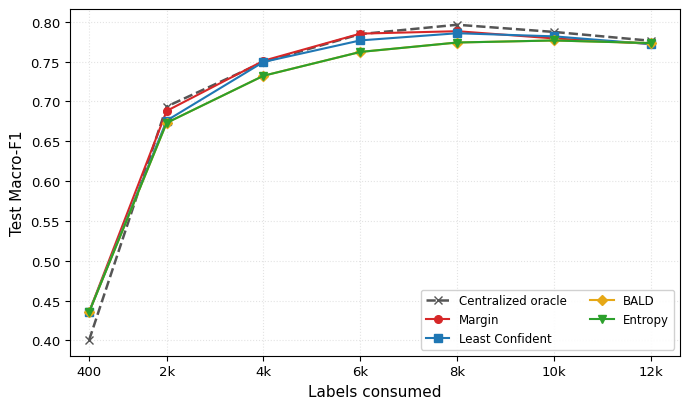

In [5]:
df = combined.copy()
METHODS = ['margin', 'least_confident', 'bald', 'entropy']
LABELS  = {'margin': 'Margin', 'least_confident': 'Least Confident', 'bald': 'BALD', 'entropy': 'Entropy'}
COLORS  = {'margin': '#d62728', 'least_confident': '#1f77b4', 'bald': '#e6a817', 'entropy': '#2ca02c'}
MARKERS = {'margin': 'o', 'least_confident': 's', 'bald': 'D', 'entropy': 'v'}

SHOW_AT = [400, 2000, 4000, 6000, 8000, 10000, 12000]

fig, ax = plt.subplots(figsize=(7, 4.2))

cen = df[(df['mode'] == 'centralized') & (df['al_method_cfg'] == 'margin')].sort_values('labels')
cen_sub = cen[cen['labels'].isin(SHOW_AT)]
ax.plot(cen_sub['labels'], cen_sub['test_rf_macro_f1'], color='#555555', ls='--', lw=1.8,
        marker='x', markersize=6, zorder=2, label='Centralized oracle')

for m in METHODS:
    fed = df[(df['mode'] == 'federated') & (df['al_method_cfg'] == m)].sort_values('labels')
    fed_sub = fed[fed['labels'].isin(SHOW_AT)]
    ax.plot(fed_sub['labels'], fed_sub['test_rf_macro_f1'], color=COLORS[m], lw=1.5, zorder=3,
            marker=MARKERS[m], markersize=5.5, label=LABELS[m])

ax.set_xlabel('Labels consumed', fontsize=11)
ax.set_ylabel('Test Macro-F1', fontsize=11)
ax.set_xlim(0, 12600)
ax.set_xticks(SHOW_AT)
ax.set_xticklabels([f'{v // 1000}k' if v >= 1000 else str(v) for v in SHOW_AT])
ax.tick_params(labelsize=9.5)
ax.grid(True, ls=':', alpha=0.35)
ax.legend(fontsize=8.5, loc='lower right', framealpha=0.9, ncol=2)

fig.tight_layout()
fig.savefig('figures/exp1_learning_curves.png', dpi=300, bbox_inches='tight')
# fig.show()

In [42]:
all_dfs_clients = []
all_dfs_runs = []
for folder in Path("runs/fel_sweeps/2_scalability/").iterdir():
    if folder.is_dir():
        rdf, client_df = run_folder_to_df_with_clients(folder)
        all_dfs_clients.append(client_df)
        all_dfs_runs.append(rdf)
combined_clients = pd.concat(all_dfs_clients, ignore_index=True)
combined_runs = pd.concat(all_dfs_runs, ignore_index=True)
combined_clients.to_csv("exp2_rounds_clients.csv", index=False)
combined_runs.to_csv("exp2_rounds_runs.csv", index=False)

In [40]:
combined_runs.columns

Index(['round', 'labels', 'labels_total', 'mode', 'macro_f1', 'rf_macro_f1',
       'meta_macro_f1', 'rf_bal_acc', 'meta_bal_acc', 'rf_auc_ovr',
       'meta_auc_ovr', 'test_macro_f1', 'test_rf_macro_f1',
       'test_meta_macro_f1', 'test_rf_bal_acc', 'test_meta_bal_acc',
       'test_rf_auc_ovr', 'test_meta_auc_ovr', 'time_train_s',
       'time_meta_refresh_s', 'time_eval_s', 'time_acquire_s', 'picked_total',
       'picked_per_class', 'al_method_log', 'seed_k', 'rounds',
       'al_method_cfg', 'batch_B', 'per_class_min', 'aug_K', 'meta_mode',
       'tta_n', 'meta_lambda', 'rf_n_estimators', 'rf_max_features',
       'seeding_method', 'holdout_frac', 'partition_method', 'n_clients',
       'dirichlet_alpha', 'run_id', 'path'],
      dtype='object')

In [41]:
combined_runs[(combined_runs["run_id"] == "exp2_C30_uniform_margin_K0_seed10_B200_R90_holdout15")]

,round,labels,labels_total,mode,macro_f1,rf_macro_f1,meta_macro_f1,rf_bal_acc,meta_bal_acc,rf_auc_ovr,...,meta_lambda,rf_n_estimators,rf_max_features,seeding_method,holdout_frac,partition_method,n_clients,dirichlet_alpha,run_id,path
1050,1,210,690,federated,0.136592,0.149133,0.136592,0.228735,0.223008,0.564176,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1051,2,410,1080,federated,0.213666,0.237349,0.213666,0.280492,0.277307,0.630077,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1052,3,610,1470,federated,0.262496,0.300871,0.262496,0.322325,0.301335,0.677774,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1053,4,810,1860,federated,0.319480,0.340410,0.319480,0.356131,0.344434,0.704051,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1054,5,1010,2250,federated,0.367917,0.385191,0.367917,0.394042,0.406508,0.729462,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,86,17210,27559,federated,NaN,NaN,NaN,NaN,NaN,NaN,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1136,87,17410,27559,federated,NaN,NaN,NaN,NaN,NaN,NaN,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1137,88,17610,27559,federated,NaN,NaN,NaN,NaN,NaN,NaN,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...
1138,89,17810,27559,federated,NaN,NaN,NaN,NaN,NaN,NaN,...,1e-2,100,sqrt,k_coreset,0.15,uniform,30,inf,exp2_C30_uniform_margin_K0_seed10_B200_R90_hol...,runs/fel_sweeps/2_scalability/exp2_C30_uniform...


Saved exp2_scalability.pdf and exp2_scalability.png


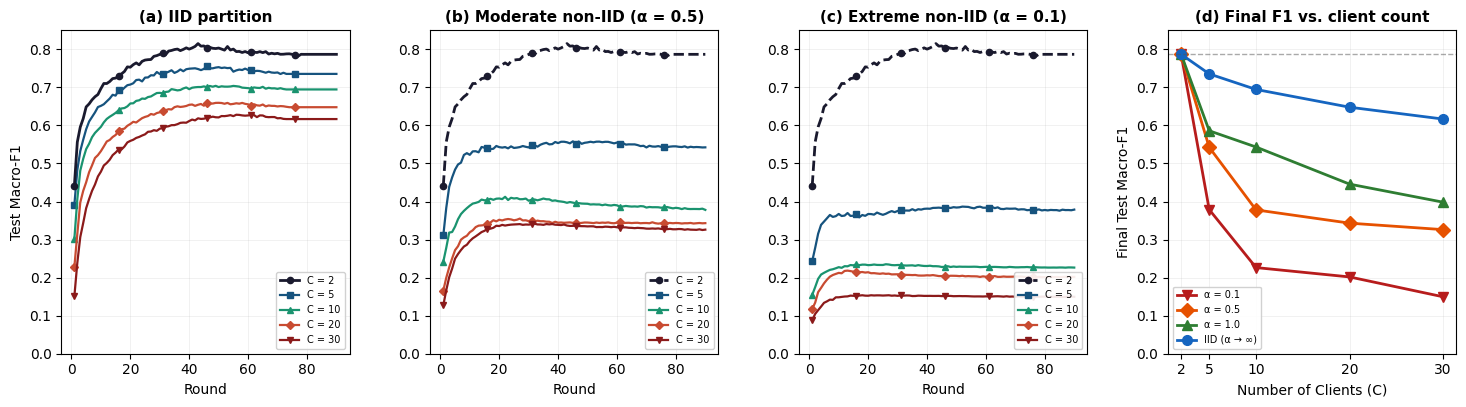

In [7]:
summary = pd.read_csv("results/exp2_summary.csv")
runs = pd.read_csv("exp2_rounds_runs.csv")
 
def parse_run(name):
    parts = name.split('_')
    C = None; alpha = None; method = "dirichlet"
    for p in parts:
        if p.startswith('C'): C = int(p[1:])
        if p.startswith('alpha'): alpha = float(p[5:])
        if p == 'uniform': method = 'uniform'; alpha = float('inf')
    if C == 2: method = 'baseline'; alpha = float('nan')
    return C, alpha, method
 
summary[['C','alpha','method']] = summary['run'].apply(lambda x: pd.Series(parse_run(x)))
runs[['C','alpha','method']] = runs['run_id'].apply(lambda x: pd.Series(parse_run(x)))
 
summary = summary[~summary['run'].str.contains('holdout30')].copy()
runs = runs[~runs['run_id'].str.contains('holdout30')].copy()
 
bl_f1 = summary.loc[summary['C']==2, 'final_test_f1'].values[0]
 
C_colors  = {2: '#1a1a2e', 5: '#16537e', 10: '#1a936f', 20: '#c84b31', 30: '#8b1a1a'}
C_markers = {2: 'o', 5: 's', 10: '^', 20: 'D', 30: 'v'}
alpha_colors  = {'0.1': '#b71c1c', '0.5': '#e65100', '1.0': '#2e7d32', 'IID': '#1565c0'}
alpha_markers = {'0.1': 'v', '0.5': 'D', '1.0': '^', 'IID': 'o'}
 
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
plt.subplots_adjust(wspace=0.28)
 
# Panel (a): IID
ax = axes[0]
c2 = runs[runs['C'] == 2]
ax.plot(c2['round'], c2['test_rf_macro_f1'], color=C_colors[2],
        marker='o', markevery=15, markersize=4.5, linewidth=2, label='C = 2', zorder=10)
for C in [5, 10, 20, 30]:
    sub = runs[(runs['C'] == C) & (runs['method'] == 'uniform')]
    if sub.empty: continue
    ax.plot(sub['round'], sub['test_rf_macro_f1'], color=C_colors[C],
            marker=C_markers[C], markevery=15, markersize=4.5, linewidth=1.6, label=f'C = {C}')
ax.set_xlabel('Round', fontsize=10); ax.set_ylabel('Test Macro-F1', fontsize=10)
ax.set_title('(a) IID partition', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.85); ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=7, loc='lower right', framealpha=0.9)
 
# Panel (b): α=0.5
ax = axes[1]
ax.plot(c2['round'], c2['test_rf_macro_f1'], color=C_colors[2],
        marker='o', markevery=15, markersize=4.5, linewidth=2, label='C = 2', linestyle='--', zorder=10)
for C in [5, 10, 20, 30]:
    sub = runs[(runs['C'] == C) & (runs['alpha'] == 0.5)]
    if sub.empty: continue
    ax.plot(sub['round'], sub['test_rf_macro_f1'], color=C_colors[C],
            marker=C_markers[C], markevery=15, markersize=4.5, linewidth=1.6, label=f'C = {C}')
ax.set_xlabel('Round', fontsize=10)
ax.set_title('(b) Moderate non-IID (α = 0.5)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.85); ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=7, loc='lower right', framealpha=0.9)
 
# Panel (c): α=0.1
ax = axes[2]
ax.plot(c2['round'], c2['test_rf_macro_f1'], color=C_colors[2],
        marker='o', markevery=15, markersize=4.5, linewidth=2, label='C = 2', linestyle='--', zorder=10)
for C in [5, 10, 20, 30]:
    sub = runs[(runs['C'] == C) & (runs['alpha'] == 0.1)]
    if sub.empty: continue
    ax.plot(sub['round'], sub['test_rf_macro_f1'], color=C_colors[C],
            marker=C_markers[C], markevery=15, markersize=4.5, linewidth=1.6, label=f'C = {C}')
ax.set_xlabel('Round', fontsize=10)
ax.set_title('(c) Extreme non-IID (α = 0.1)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.85); ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=7, loc='lower right', framealpha=0.9)
 
# Panel (d): Final F1 vs C
ax = axes[3]
C_vals = [2, 5, 10, 20, 30]
for alabel in ['0.1', '0.5', '1.0', 'IID']:
    Cs = []; f1s = []
    for C in C_vals:
        if C == 2:
            row = summary[summary['C'] == 2]
        elif alabel == 'IID':
            row = summary[(summary['C'] == C) & (summary['method'] == 'uniform')]
        else:
            row = summary[(summary['C'] == C) & (summary['alpha'] == float(alabel))]
        if not row.empty:
            Cs.append(C); f1s.append(row['final_test_f1'].values[0])
    lbl = f'α = {alabel}' if alabel != 'IID' else 'IID (α → ∞)'
    ax.plot(Cs, f1s, color=alpha_colors[alabel], marker=alpha_markers[alabel],
            linewidth=2, markersize=7, label=lbl)
ax.axhline(y=bl_f1, color='#555', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Number of Clients (C)', fontsize=10); ax.set_ylabel('Final Test Macro-F1', fontsize=10)
ax.set_title('(d) Final F1 vs. client count', fontsize=11, fontweight='bold')
ax.set_xticks(C_vals); ax.set_ylim(0, 0.85); ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=7, loc='lower left', framealpha=0.9)
 
# plt.savefig('exp2_scalability.pdf', bbox_inches='tight', dpi=150)
plt.savefig('exp2_scalability.png', bbox_inches='tight', dpi=200)
print("Saved exp2_scalability.pdf and exp2_scalability.png")

In [10]:
all_dfs_clients = []
all_dfs_runs = []
for folder in Path("runs/fel_sweeps/3_meta_ablation/").iterdir():
    if folder.is_dir():
        rdf, client_df = run_folder_to_df_with_clients(folder)
        all_dfs_clients.append(client_df)
        all_dfs_runs.append(rdf)
combined_clients = pd.concat(all_dfs_clients, ignore_index=True)
combined_runs = pd.concat(all_dfs_runs, ignore_index=True)
combined_clients.to_csv("exp3_rounds_clients.csv", index=False)
combined_runs.to_csv("exp3_rounds_runs.csv", index=False)

Saved exp3_ablation.pdf and exp3_ablation.png


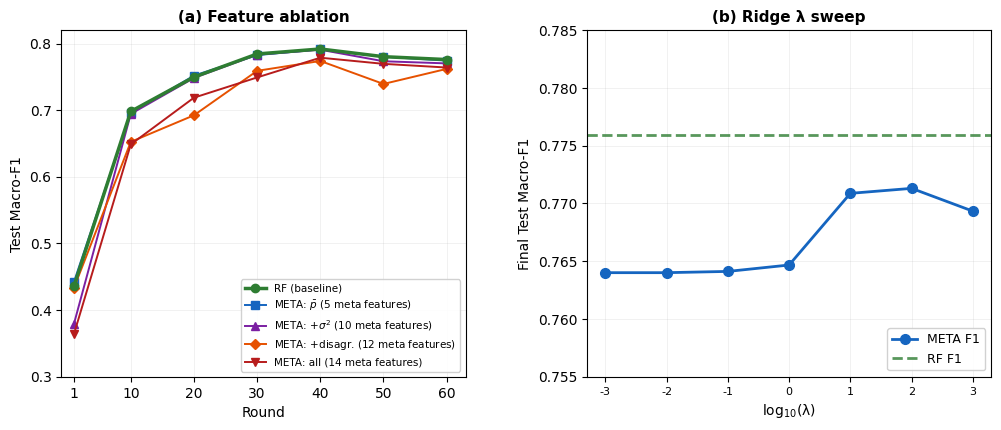

In [20]:
runs = pd.read_csv("exp3_rounds_runs.csv")
summary = pd.read_csv("results/exp3_summary.csv")
 
sample_rounds = [1, 10, 20, 30, 40, 50, 60]
 
def parse_run(name):
    if 'feat_' in name:
        fg = name.split('feat_')[1].split('_margin')[0]
        return 'feature', fg, 0.01
    elif 'lambda_' in name:
        lam_str = name.split('lambda_')[1].split('_margin')[0]
        return 'lambda', 'all', float(lam_str)
    return 'unknown', '', 0
 
summary[['sweep','feat_label','lam']] = summary['run'].apply(lambda x: pd.Series(parse_run(x)))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plt.subplots_adjust(wspace=0.30)
 
# ---- Panel (a): Feature ablation per round ----
ax = axes[0]
feat_runs = runs[runs['run_id'].str.contains('feat_')].copy()
feat_runs['feat_label'] = feat_runs['run_id'].apply(
    lambda x: x.split('feat_')[1].split('_margin')[0])
feat_runs = feat_runs[feat_runs['round'].isin(sample_rounds)]
 
rf_line = feat_runs[feat_runs['feat_label']=='mean_p'].sort_values('round')
ax.plot(rf_line['round'], rf_line['test_rf_macro_f1'], color='#2e7d32',
        linewidth=2.5, marker='o', markersize=6, label='RF (baseline)', zorder=10)
 
colors_f = {'mean_p': '#1565c0', 'mean_p+var_p': '#7b1fa2',
            'mean_p+var_p+disagreement': '#e65100',
            'mean_p+var_p+disagreement+uncertainty': '#b71c1c'}
labels_f = {'mean_p': 'META: $\\bar{p}$ (5 meta features)',
            'mean_p+var_p': 'META: $+\\sigma^2$ (10 meta features)',
            'mean_p+var_p+disagreement': 'META: $+$disagr. (12 meta features)',
            'mean_p+var_p+disagreement+uncertainty': 'META: all (14 meta features)'}
markers_f = {'mean_p': 's', 'mean_p+var_p': '^',
             'mean_p+var_p+disagreement': 'D',
             'mean_p+var_p+disagreement+uncertainty': 'v'}
 
for fg in ['mean_p', 'mean_p+var_p', 'mean_p+var_p+disagreement',
           'mean_p+var_p+disagreement+uncertainty']:
    sub = feat_runs[feat_runs['feat_label']==fg].sort_values('round')
    ax.plot(sub['round'], sub['test_meta_macro_f1'], color=colors_f[fg],
            marker=markers_f[fg], markersize=5.5, linewidth=1.4, label=labels_f[fg])
 
ax.set_xlabel('Round', fontsize=10)
ax.set_ylabel('Test Macro-F1', fontsize=10)
ax.set_title('(a) Feature ablation', fontsize=11, fontweight='bold')
ax.set_ylim(0.3, 0.82)
ax.set_xlim(-1, 63)
ax.set_xticks(sample_rounds)
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.9)
 
# ---- Panel (b): Lambda sweep — final F1 only ----
ax = axes[1]
lam_rows = summary[summary['sweep']=='lambda'].sort_values('lam')
lambdas = lam_rows['lam'].values
meta_f1 = lam_rows['final_meta_f1'].values
rf_f1 = lam_rows['final_rf_f1'].values[0]
 
ax.plot(np.log10(lambdas), meta_f1, 'o-', color='#1565c0', linewidth=2,
        markersize=7, label='META F1')
ax.axhline(y=rf_f1, color='#2e7d32', linestyle='--', linewidth=2,
           label='RF F1', alpha=0.8)
 
ax.set_xlabel('log$_{10}$(λ)', fontsize=10)
ax.set_ylabel('Final Test Macro-F1', fontsize=10)
ax.set_title('(b) Ridge λ sweep', fontsize=11, fontweight='bold')
ax.set_ylim(0.755, 0.785)
ax.set_xticks(np.log10(lambdas))
ax.set_xticklabels([int(v) for v in np.log10(lambdas)], fontsize=8)
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
 
plt.savefig('exp3_ablation.pdf', bbox_inches='tight', dpi=150)
plt.savefig('exp3_ablation.png', bbox_inches='tight', dpi=200)
print("Saved exp3_ablation.pdf and exp3_ablation.png")

In [4]:
all_dfs_clients = []
all_dfs_runs = []
for folder in Path("runs/fel_sweeps/3c_emb_noise/").iterdir():
    if folder.is_dir():
        rdf, client_df = run_folder_to_df_with_clients(folder)
        all_dfs_clients.append(client_df)
        all_dfs_runs.append(rdf)
combined_clients = pd.concat(all_dfs_clients, ignore_index=True)
combined_runs = pd.concat(all_dfs_runs, ignore_index=True)
combined_clients.to_csv("exp3c_rounds_clients.csv", index=False)
combined_runs.to_csv("exp3c_rounds_runs.csv", index=False)

In [5]:
all_dfs_clients = []
all_dfs_runs = []
for folder in Path("runs/fel_sweeps/3d_hetero_models/").iterdir():
    if folder.is_dir():
        rdf, client_df = run_folder_to_df_with_clients(folder)
        all_dfs_clients.append(client_df)
        all_dfs_runs.append(rdf)
combined_clients = pd.concat(all_dfs_clients, ignore_index=True)
combined_runs = pd.concat(all_dfs_runs, ignore_index=True)
combined_clients.to_csv("exp3d_rounds_clients.csv", index=False)
combined_runs.to_csv("exp3d_rounds_runs.csv", index=False)

In [7]:
combined_clients

,round,labels,client,model_type,L_size,U_size,rf_macro_f1,meta_macro_f1,rf_bal_acc,meta_bal_acc,...,holdout_frac,partition_method,n_clients,dirichlet_alpha,feature_groups,heterogeneous_rf,emb_noise_stds,client_model_types,run_id,path
0,1,400,MENDELEY_0,RF,280,4077,0.572701,0.571560,0.582414,0.589273,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
1,1,400,MENDELEY_1,Logistic,280,4083,0.687890,0.685025,0.685721,0.683394,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
2,1,400,MENDELEY_2,SVM,280,4076,0.563418,0.580583,0.609308,0.621104,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
3,1,400,RSNA_0,MLP,280,4532,0.483727,0.482736,0.501321,0.499607,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
4,1,400,RSNA_1,GBT,280,4528,0.365380,0.365235,0.397601,0.397915,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,60,12200,MENDELEY_0,RF,4357,0,NaN,NaN,NaN,NaN,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
296,60,12200,MENDELEY_1,Logistic,4363,0,NaN,NaN,NaN,NaN,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
297,60,12200,MENDELEY_2,SVM,4356,0,NaN,NaN,NaN,NaN,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...
298,60,12200,RSNA_0,MLP,4812,0,NaN,NaN,NaN,NaN,...,0.3,uniform,5,inf,"mean_p,uncertainty",None,None,"[""rf"", ""logistic"", ""svm"", ""mlp"", ""gbt""]",exp3d_mixed_margin_K0_seed200_B200_R60_holdout30,runs/fel_sweeps/3d_hetero_models/exp3d_mixed_m...


Saved exp3c_noise_curves.pdf and exp3c_noise_curves.png


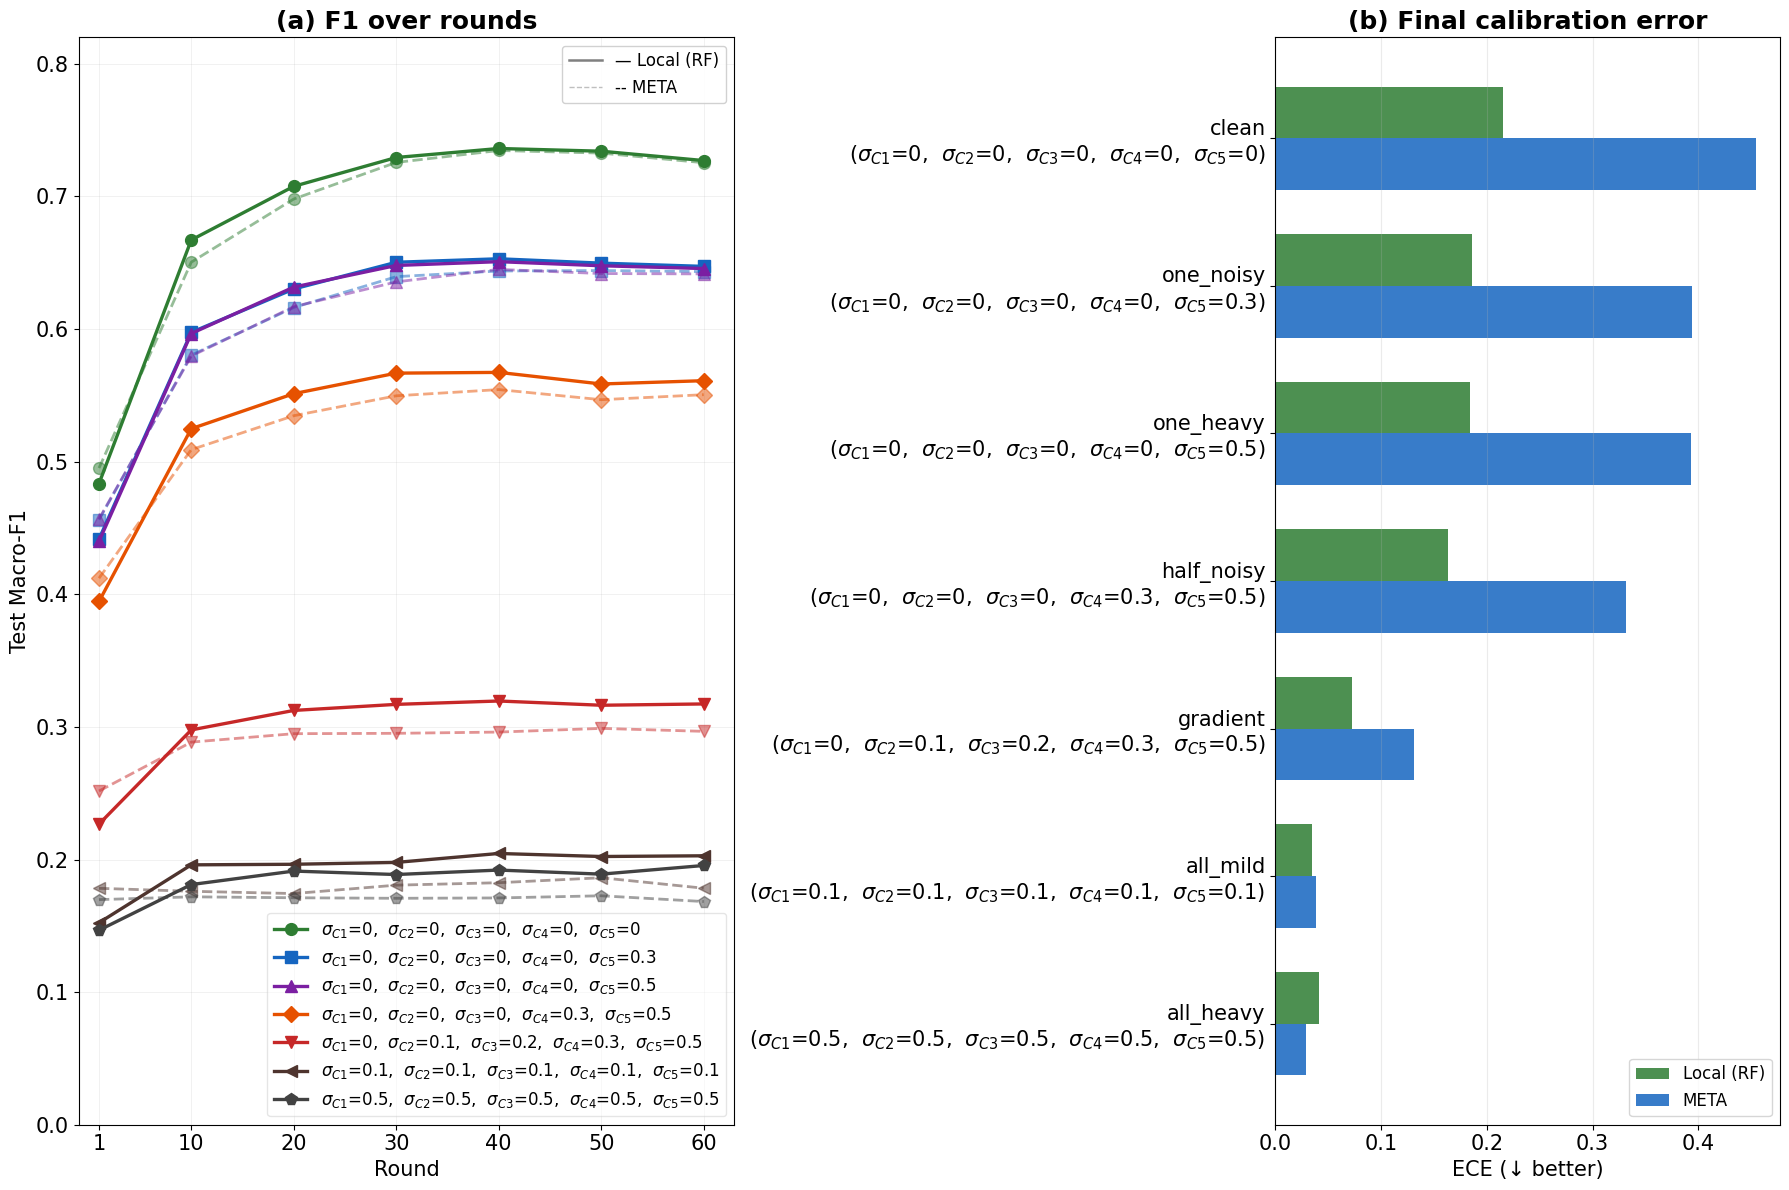

In [37]:
runs3c = pd.read_csv("exp3c_rounds_runs.csv")
s3c = pd.read_csv("results/exp3c_summary.csv")
 
sample_rounds = [1, 10, 20, 30, 40, 50, 60]
runs3c['level'] = runs3c['run_id'].apply(lambda x: x.split('noise_')[1].split('_margin')[0])
runs3c_s = runs3c[runs3c['round'].isin(sample_rounds)]
s3c['level'] = s3c['run'].apply(lambda x: x.split('noise_')[1].split('_margin')[0])
 
# Per-client sigma values
sigma_vals = {
    'clean':      [0, 0, 0, 0, 0],
    'one_noisy':  [0, 0, 0, 0, 0.3],
    'one_heavy':  [0, 0, 0, 0, 0.5],
    'half_noisy': [0, 0, 0, 0.3, 0.5],
    'gradient':   [0, 0.1, 0.2, 0.3, 0.5],
    'all_mild':   [0.1, 0.1, 0.1, 0.1, 0.1],
    'all_heavy':  [0.5, 0.5, 0.5, 0.5, 0.5],
}
 
def sigma_legend(sigmas):
    parts = [f'$\\sigma_{{C{i+1}}}$={s}' for i, s in enumerate(sigmas)]
    return ',  '.join(parts)
 
def bar_ylabel(name, sigmas):
    params = ',  '.join([f'$\\sigma_{{C{i+1}}}$={s}' for i, s in enumerate(sigmas)])
    return f'{name}\n({params})'
 
legend_labels = {k: sigma_legend(v) for k, v in sigma_vals.items()}
bar_ylabels = {k: bar_ylabel(k, v) for k, v in sigma_vals.items()}
 
order = ['clean', 'one_noisy', 'one_heavy', 'half_noisy', 'gradient', 'all_mild', 'all_heavy']
colors = {
    'clean': '#2e7d32', 'one_noisy': '#1565c0', 'one_heavy': '#7b1fa2',
    'half_noisy': '#e65100', 'gradient': '#c62828', 'all_mild': '#4e342e', 'all_heavy': '#424242',
}
markers = {
    'clean': 'o', 'one_noisy': 's', 'one_heavy': '^',
    'half_noisy': 'D', 'gradient': 'v', 'all_mild': '<', 'all_heavy': 'p',
}
 
fig, axes = plt.subplots(1, 2, figsize=(18, 12), gridspec_kw={'width_ratios': [1.3, 1]})
plt.subplots_adjust(wspace=0.45)
 
# ---- Panel (a): Learning curves ----
ax = axes[0]
for level in order:
    sub = runs3c_s[runs3c_s['level']==level].sort_values('round')
    ax.plot(sub['round'], sub['test_rf_macro_f1'], color=colors[level],
            marker=markers[level], markersize=8.5, linewidth=2.4,
            label=legend_labels[level])
    ax.plot(sub['round'], sub['test_meta_macro_f1'], color=colors[level],
            marker=markers[level], markersize=8.5, linewidth=2.0,
            linestyle='--', alpha=0.5)
 
custom = [
    Line2D([0], [0], color='gray', linewidth=1.8, label='— Local (RF)'),
    Line2D([0], [0], color='gray', linewidth=1.0, linestyle='--', alpha=0.5, label='-- META'),
]
leg1 = ax.legend(fontsize=12, loc='lower right', framealpha=0.5)
leg2 = ax.legend(handles=custom, fontsize=12, loc='upper right', framealpha=0.9)
ax.add_artist(leg1)
 
ax.set_xlabel('Round', fontsize=15)
ax.set_ylabel('Test Macro-F1', fontsize=15)
ax.set_title('(a) F1 over rounds', fontsize=18, fontweight='bold')
ax.set_ylim(0.0, 0.82)
ax.set_xlim(-1, 63)
ax.set_xticks(sample_rounds)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.grid(True, alpha=0.25, linewidth=0.5)
 
# ---- Panel (b): ECE bar plot ----
ax = axes[1]
s3c_s = s3c.set_index('level').reindex(order)
 
x = np.arange(len(order))
w = 0.35
 
ax.barh(x - w/2, s3c_s['final_rf_ece'].values, w, label='Local (RF)', color='#2e7d32', alpha=0.85)
ax.barh(x + w/2, s3c_s['final_meta_ece'].values, w, label='META', color='#1565c0', alpha=0.85)
 
ax.set_yticks(x)
ax.set_yticklabels([bar_ylabels[l] for l in order], fontsize=15)
ax.set_xlabel('ECE (↓ better)', fontsize=15)
ax.set_title('(b) Final calibration error', fontsize=18, fontweight='bold')
ax.tick_params(axis='x', labelsize=15)
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()

plt.tight_layout()
 
# plt.savefig('exp3c_noise_curves.pdf', bbox_inches='tight', dpi=150)
plt.savefig('exp3c_noise_curves.png', bbox_inches='tight', dpi=300)
print("Saved exp3c_noise_curves.pdf and exp3c_noise_curves.png")

In [4]:
all_dfs_clients = []
all_dfs_runs = []
for folder in Path("runs/fel_sweeps/5_fed_baselines/").iterdir():
    if folder.is_dir():
        rdf, client_df = run_folder_to_df_with_clients(folder)
        all_dfs_clients.append(client_df)
        all_dfs_runs.append(rdf)
combined_clients = pd.concat(all_dfs_clients, ignore_index=True)
combined_runs = pd.concat(all_dfs_runs, ignore_index=True)
combined_clients.to_csv("exp5_rounds_clients.csv", index=False)
combined_runs.to_csv("exp5_rounds_runs.csv", index=False)

/tmp/ipykernel_723100/3364626550.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_clients = pd.concat(all_dfs_clients, ignore_index=True)
/tmp/ipykernel_723100/3364626550.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_runs = pd.concat(all_dfs_runs, ignore_index=True)


Saved exp5_baselines.pdf and exp5_baselines.png


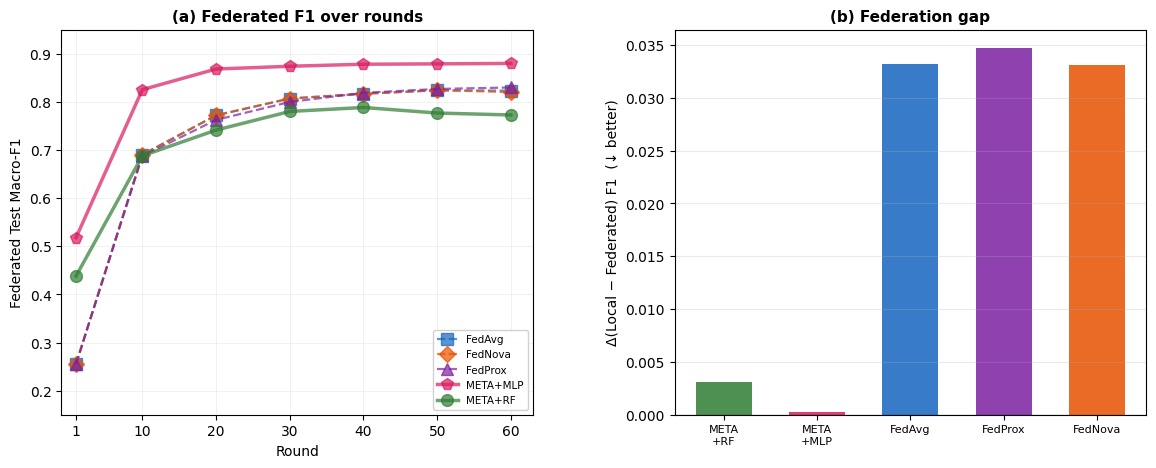

In [22]:
runs = pd.read_csv("exp5_rounds_runs.csv")
sample_rounds = [1, 10, 20, 30, 40, 50, 60]

method_map = {
    'frml_rf':  ('META+RF',   '#2e7d32', 'o', '-',  2.5),
    'frml_mlp': ('META+MLP',  '#d81b60', 'p', '-',  2.5),
    'fedavg':   ('FedAvg',    '#1565c0', 's', '--', 1.6),
    'fedprox':  ('FedProx',   '#7b1fa2', '^', '--', 1.6),
    'fednova':  ('FedNova',   '#e65100', 'D', '--', 1.6),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(wspace=0.30)

# ---- Panel (a): Federated F1 learning curves ----
ax = axes[0]
for rid in sorted(runs['run_id'].unique()):
    method_key = rid.split('exp5_')[1].split('_margin')[0]
    label, color, marker, ls, lw = method_map[method_key]
    sub = runs[(runs['run_id']==rid) & (runs['round'].isin(sample_rounds))].sort_values('round')
    ax.plot(sub['round'], sub['test_meta_macro_f1'], color=color, alpha=0.7,
            marker=marker, markersize=8.5, linewidth=lw, linestyle=ls, label=label)

ax.set_xlabel('Round', fontsize=10)
ax.set_ylabel('Federated Test Macro-F1', fontsize=10)
ax.set_title('(a) Federated F1 over rounds', fontsize=11, fontweight='bold')
ax.set_ylim(0.15, 0.95)
ax.set_xlim(-1, 63)
ax.set_xticks(sample_rounds)
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.9)

# ---- Panel (b): Federation gap (Local − Fed), higher = worse ----
ax = axes[1]
methods_order = ['frml_rf', 'frml_mlp', 'fedavg', 'fedprox', 'fednova']
method_labels = ['META\n+RF', 'META\n+MLP', 'FedAvg', 'FedProx', 'FedNova']
bar_colors = ['#2e7d32', '#d81b60', '#1565c0', '#7b1fa2', '#e65100']

gaps = []
for mk in methods_order:
    rid = [r for r in runs['run_id'].unique() if f'exp5_{mk}_' in r][0]
    sub = runs[runs['run_id']==rid]
    last = sub[sub['round']==sub['round'].max()].iloc[0]
    gaps.append(last['test_rf_macro_f1'] - last['test_meta_macro_f1'])  # Local − Fed

x = np.arange(len(methods_order))
ax.bar(x, gaps, 0.6, color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
# for i, d in enumerate(gaps):
#     offset = 0.001 if d >= 0 else -0.001
#     va = 'bottom' if d >= 0 else 'top'
#     ax.text(i, d + offset, f'{d:.4f}', ha='center', va=va, fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(method_labels, fontsize=8)
ax.set_ylabel('Δ(Local − Federated) F1  (↓ better)', fontsize=10)
ax.set_title('(b) Federation gap', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25)

# # ---- Panel (c): Communication vs F1 scatter ----
# ax = axes[2]
# frml_comm_kb = 484 * 2 * 2 * 60 / 1024

# for mk in methods_order:
#     rid = [r for r in runs['run_id'].unique() if f'exp5_{mk}_' in r][0]
#     sub = runs[runs['run_id']==rid]
#     last = sub[sub['round']==sub['round'].max()].iloc[0]
#     fed_f1 = last['test_meta_macro_f1']

#     if 'frml' in mk:
#         comm_kb = frml_comm_kb
#     else:
#         comm_kb = last['comm_bytes_cumul'] / 1024

#     label, color, marker, _, _ = method_map[mk]
#     ax.scatter(comm_kb, fed_f1, color=color, s=150, marker=marker, zorder=10,
#               edgecolor='white', linewidth=1.5, label=label)

# ax.set_xscale('log')
# ax.set_xlabel('Total communication (KB, log scale)', fontsize=10)
# ax.set_ylabel('Federated Test Macro-F1', fontsize=10)
# ax.set_title('(c) F1 vs communication cost', fontsize=11, fontweight='bold')
# ax.set_ylim(0.72, 0.92)
# ax.grid(True, alpha=0.25, linewidth=0.5)
# ax.legend(fontsize=7.5, loc='lower right', framealpha=0.9)

# baseline_comm_kb = 17945280 / 1024
# ax.annotate('', xy=(frml_comm_kb, 0.85), xytext=(baseline_comm_kb, 0.85),
#             arrowprops=dict(arrowstyle='<->', color='#c62828', lw=1.5))
# ax.text(np.sqrt(frml_comm_kb * baseline_comm_kb), 0.858, '154× less\ncommunication',
#         ha='center', fontsize=8, color='#c62828', fontweight='bold')

# plt.tight_layout()

# plt.savefig('exp5_baselines.pdf', bbox_inches='tight', dpi=150)
plt.savefig('exp5_baselines.png', bbox_inches='tight', dpi=300)
print("Saved exp5_baselines.pdf and exp5_baselines.png")